# Long Format vs Wide Format: Reshaping Data with pandas

**Dataset.** ECDC daily COVID-19 reports, 31 Dec 2019 - 19 Sep 2020. One row per country per day, 43,718 rows across 210 countries and territories.

**The idea.** The *same data* can be arranged in different shapes, and the shape you choose determines which operations are easy and which are painful. There is no universally correct shape. There is only the shape that fits the question.

This notebook works through three things:

1. **Long format** - what it is, and how to recognise it
2. **Converting long to wide** - three different pandas routes, and when each one applies
3. **Wide format** - the operations it makes natural

By the end you should be able to look at a task and predict which shape you want *before* you start writing code.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (11, 5)

In [2]:
URL = 'https://raw.githubusercontent.com/thousandoaks/Python4DS-II/main/datasets/covid19_cases.csv'

try:
    df = pd.read_csv(URL)
except Exception:
    df = pd.read_csv('covid19_cases.csv')   # local fallback

# dateRep arrives as dd/mm/yyyy text. Without an explicit format pandas may
# guess month-first and silently produce wrong dates.
df['dateRep'] = pd.to_datetime(df['dateRep'], format='%d/%m/%Y')

# Country names use underscores. Strip them for readable chart labels,
# and keep this as the column we reshape on later.
df['country'] = df['countriesAndTerritories'].str.replace('_', ' ', regex=False)

print(df.shape)
df.head()

(43718, 13)


,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,country
0,2020-09-19,19,9,2020,47,1,Afghanistan,AF,AFG,38041757.0,Asia,1.616645,Afghanistan
1,2020-09-18,18,9,2020,0,0,Afghanistan,AF,AFG,38041757.0,Asia,1.535155,Afghanistan
2,2020-09-17,17,9,2020,17,0,Afghanistan,AF,AFG,38041757.0,Asia,1.653446,Afghanistan
3,2020-09-16,16,9,2020,40,10,Afghanistan,AF,AFG,38041757.0,Asia,1.708649,Afghanistan
4,2020-09-15,15,9,2020,99,6,Afghanistan,AF,AFG,38041757.0,Asia,1.627159,Afghanistan


## 0. What are we looking at?

Before reshaping anything, get oriented.

In [3]:
print('rows, columns :', df.shape)
print('date range    :', df['dateRep'].min().date(), '->', df['dateRep'].max().date())
print('countries     :', df['country'].nunique())
print('continents    :', sorted(df['continentExp'].unique()))
print()
df.dtypes

rows, columns : (43718, 13)
date range    : 2019-12-31 -> 2020-09-19
countries     : 210
continents    : ['Africa', 'America', 'Asia', 'Europe', 'Oceania', 'Other']



dateRep                                                       datetime64[ns]
day                                                                    int64
month                                                                  int64
year                                                                   int64
cases                                                                  int64
deaths                                                                 int64
countriesAndTerritories                                               object
geoId                                                                 object
countryterritoryCode                                                  object
popData2019                                                          float64
continentExp                                                          object
Cumulative_number_for_14_days_of_COVID-19_cases_per_100000           float64
country                                                               object

---

# 1. Long Format

## 1.1 Anatomy

A dataset is in **long format** (also called *tidy* or *stacked*) when:

- each row is a single observation
- each column is a single variable
- the columns split into **identifier variables** that say *which* observation this is, and **value variables** that carry the measurement

In our data, one observation is *"one country on one day"*:

| role | columns |
|---|---|
| **identifiers** | `dateRep`, `country` |
| **values** | `cases`, `deaths` |
| **attributes** (constant per country) | `geoId`, `countryterritoryCode`, `popData2019`, `continentExp` |

The crucial structural fact: **country names live in the data, not in the column names.** Adding a 211th country adds rows, not columns. The shape of the table does not change when the data grows.

In [4]:
# The same country appears on many rows - identity is a value, not a position.
df[df['country'] == 'Spain'].head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2019,continentExp,Cumulative_number_for_14_days_of_COVID-19_cases_per_100000,country
37300,2020-09-18,18,9,2020,14389,90,Spain,ES,ESP,46937060.0,Europe,300.510940,Spain
37301,2020-09-17,17,9,2020,11291,162,Spain,ES,ESP,46937060.0,Europe,292.174244,Spain
37302,2020-09-16,16,9,2020,11193,239,Spain,ES,ESP,46937060.0,Europe,287.205888,Spain
37303,2020-09-15,15,9,2020,9437,156,Spain,ES,ESP,46937060.0,Europe,281.640989,Spain
37304,2020-09-14,14,9,2020,27404,101,Spain,ES,ESP,46937060.0,Europe,278.824451,Spain


In [5]:
# Adding a country would add rows, never columns.
print('columns          :', len(df.columns))
print('distinct countries:', df['country'].nunique())
print('rows             :', len(df))

columns          : 13
distinct countries: 210
rows             : 43718


---

# 2. Converting Long to Wide

## 2.1 What we are asking for

We want a table where:

- each **row** is a date
- each **column** is a country
- each **cell** is that country's case count on that date

That means choosing three things:

| choice | our answer | pandas argument |
|---|---|---|
| what identifies a row | `dateRep` | `index=` |
| what becomes the columns | `country` | `columns=` |
| what fills the cells | `cases` | `values=` |

Every reshaping method below is just a different way of expressing those same three choices. Getting them straight in your head first makes the API differences trivial.

## 2.2 Route 1: `pivot()`

The most direct route. `pivot()` is a **pure rearrangement** - it moves values around without combining them.

Because of that it has a hard requirement: **every (index, column) pair must be unique.** If two rows claim the same date *and* the same country, `pivot()` cannot decide which value belongs in the cell, so it refuses.

In [6]:
wide_cases = df.pivot(index='dateRep', columns='country', values='cases')

print('long:', df.shape)
print('wide:', wide_cases.shape)
wide_cases.iloc[:5, :6]

long: (43718, 13)
wide: (264, 210)


country,Afghanistan,Albania,Algeria,Andorra,Angola,Anguilla
dateRep,,,,,,
2019-12-31,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-01,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-02,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-03,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-04,0.0,NaN,0.0,NaN,NaN,NaN


43,718 rows became a 264 x 210 grid. The same numbers, arranged as a matrix.

Look at what happened to the identifiers: `dateRep` became the **index**, and `country` became the **column labels**. Country identity moved *out of the data and into the schema* - the exact inverse of the long-format property from section 1.1.

In [7]:
print('index :', wide_cases.index.name, '|', wide_cases.index.dtype)
print('columns:', wide_cases.columns.name, '|', wide_cases.columns.dtype)
print()
print('first 8 columns:', list(wide_cases.columns[:8]))

index : dateRep | datetime64[ns]
columns: country | object

first 8 columns: ['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina']


### When `pivot()` fails

Worth seeing the error once, deliberately, so you recognise it later. Here we duplicate a single row to create a collision.

In [8]:
broken = pd.concat([df, df.head(1)], ignore_index=True)

try:
    broken.pivot(index='dateRep', columns='country', values='cases')
except ValueError as e:
    print('ValueError:', e)

ValueError: Index contains duplicate entries, cannot reshape


`Index contains duplicate entries, cannot reshape.` In practice this fires when your index/column pair does not actually identify a row - for example pivoting on `month` instead of `dateRep`, where each country legitimately has ~30 rows per month.

## 2.3 Route 2: `pivot_table()`

`pivot_table()` handles exactly that case. It **aggregates** rather than rearranges: when several rows land in one cell, `aggfunc` decides how to combine them. It defaults to `mean`.

For our data at daily resolution nothing collides, so `pivot_table(aggfunc='sum')` returns the same numbers as `pivot()` - just via a different mechanism.

In [9]:
wide_pt = df.pivot_table(index='dateRep', columns='country',
                         values='cases', aggfunc='sum')

print('identical to pivot() output? ',
      wide_pt.equals(wide_cases.astype(wide_pt.dtypes.iloc[0])))
wide_pt.iloc[:5, :6]

identical to pivot() output?  True


country,Afghanistan,Albania,Algeria,Andorra,Angola,Anguilla
dateRep,,,,,,
2019-12-31,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-01,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-02,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-03,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-04,0.0,NaN,0.0,NaN,NaN,NaN


Where `pivot_table()` becomes indispensable is when you *want* the aggregation - pivoting to a coarser time grain, for instance. Monthly totals per country:

In [10]:
monthly = df.pivot_table(index=['year', 'month'], columns='country',
                         values='cases', aggfunc='sum')

# pivot() would raise here: ~30 rows per country share each (year, month) pair.
monthly.iloc[:, :6]

country     Afghanistan  Albania  Algeria  Andorra  Angola  Anguilla
year month                                                          
2019 12             0.0      NaN      0.0      NaN     NaN       NaN
2020 1              0.0      NaN      0.0      NaN     NaN       NaN
     2              1.0      NaN      1.0      NaN     NaN       NaN
     3            140.0    223.0    583.0    370.0     7.0       2.0
     4           1808.0    543.0   3264.0    373.0    20.0       1.0
     5          12576.0    356.0   5419.0     21.0    57.0       0.0
     6          16713.0   1344.0   4304.0     91.0   192.0       0.0
     7           5304.0   2731.0  16260.0     67.0   802.0       0.0
     8           1620.0   4183.0  14315.0    202.0  1546.0       0.0
     9            757.0   2693.0   5267.0    440.0  1165.0       0.0

`pivot_table()` also does several value columns at once, producing a hierarchical column index:

In [11]:
both = df.pivot_table(index='dateRep', columns='country',
                      values=['cases', 'deaths'], aggfunc='sum')

print(both.columns.names)
both.loc[:, (slice(None), ['Spain', 'Italy'])].head()

[None, 'country']


,cases,deaths,cases,deaths
country,Spain,Spain,Italy,Italy
dateRep,,,,
2019-12-31,0.0,0.0,0.0,0.0
2020-01-01,0.0,0.0,0.0,0.0
2020-01-02,0.0,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.0


## 2.4 Route 3: `set_index()` + `unstack()`

The third route is the most general, and understanding it explains what the other two are doing underneath.

The idea: make **both** identifiers into a MultiIndex, then push one index level up into the columns. `unstack()` is that push.

In [12]:
stacked = df.set_index(['dateRep', 'country'])['cases']
print(type(stacked).__name__, '| index levels:', stacked.index.names)
stacked.head()

Series | index levels: ['dateRep', 'country']


dateRep     country    
2020-09-19  Afghanistan    47
2020-09-18  Afghanistan     0
2020-09-17  Afghanistan    17
2020-09-16  Afghanistan    40
2020-09-15  Afghanistan    99
Name: cases, dtype: int64

In [13]:
wide_us = stacked.unstack('country')

print('same as pivot() result?', wide_us.equals(wide_cases))
wide_us.iloc[:5, :6]

same as pivot() result? True


country,Afghanistan,Albania,Algeria,Andorra,Angola,Anguilla
dateRep,,,,,,
2019-12-31,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-01,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-02,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-03,0.0,NaN,0.0,NaN,NaN,NaN
2020-01-04,0.0,NaN,0.0,NaN,NaN,NaN


Identical. `unstack()` names the level you want to move; `unstack(0)` would move dates into the columns and give you the transposed layout instead.

This route is the one to reach for when you already have a MultiIndex from a `groupby`, since the data is halfway there already:

In [14]:
(df.groupby(['continentExp', 'year', 'month'])['cases']
   .sum()
   .unstack('continentExp'))

continentExp    Africa    America       Asia    Europe  Oceania  Other
year month                                                            
2019 12            0.0        0.0       27.0       0.0      0.0    0.0
2020 1             0.0        9.0     9766.0      15.0      7.0    0.0
     2             3.0       76.0    73470.0    1139.0     19.0  705.0
     3          5134.0   188660.0    85871.0  437425.0   5298.0   -9.0
     4         31598.0  1104862.0   333821.0  857419.0   2812.0    NaN
     5        104887.0  1552784.0   592831.0  623096.0    503.0    NaN
     6        251822.0  2379672.0  1119998.0  480791.0    705.0    NaN
     7        516291.0  4112251.0  1929728.0  486132.0   8750.0    NaN
     8        336450.0  4058338.0  2799266.0  772082.0  11296.0    NaN
     9        145056.0  2100303.0  2232999.0  783467.0   2821.0    NaN

## 2.5 Choosing a route

| method | aggregates? | multiple value columns | use when |
|---|---|---|---|
| `pivot()` | no - raises on duplicates | no | index/column pair is already unique |
| `pivot_table()` | yes, via `aggfunc` | yes | duplicates exist, or you want a coarser grain |
| `set_index().unstack()` | no | via column selection | data is already indexed, or output of a `groupby` |

They are not really three tools. They are three doors into the same room.

## 2.6 The NaNs are real

One thing to understand before moving on. Our wide table is 264 x 210 = 55,440 cells, but the long data had only 43,718 rows. About 21% of cells have no source row and are therefore `NaN`.

This is not corruption. Countries entered the dataset when they reported their first case, so coverage is genuinely uneven - between 64 and 264 days each.

In [15]:
print('wide cells   :', wide_cases.size)
print('long rows    :', len(df))
print('NaN cells    :', int(wide_cases.isna().sum().sum()))
print('NaN share    : {:.1%}'.format(wide_cases.isna().sum().sum() / wide_cases.size))
print()
days = df.groupby('country')['dateRep'].nunique()
print('days of coverage per country: min {}, median {}, max {}'
      .format(days.min(), int(days.median()), days.max()))

wide cells   : 55440
long rows    : 43718
NaN cells    : 11722
NaN share    : 21.1%

days of coverage per country: min 64, median 190, max 264


**This is a reshaping lesson, not an accident.** Long format hides uneven coverage - a country with 64 days simply has 64 rows and nothing looks amiss. Wide format forces the gaps into view as explicit `NaN` cells, because the rectangle has to be filled.

That is a genuine advantage of the wide layout: *it makes missingness visible.*

For the analyses in section 3 we treat "did not report" as zero. That is a defensible assumption for pre-first-case dates and a questionable one for mid-series gaps - which is precisely the kind of judgement call reshaping tends to surface.

In [16]:
wide = wide_cases.fillna(0)
wide_deaths = df.pivot(index='dateRep', columns='country', values='deaths').fillna(0)

print(wide.shape, '| NaNs remaining:', int(wide.isna().sum().sum()))

(264, 210) | NaNs remaining: 0


---

# 3. Wide Format

Wide format turns the dataset into a **matrix**: rows indexed by time, columns indexed by entity, numbers in between. Everything that follows exploits that structure.

The unifying principle: in wide format, **countries are aligned by position**. Row *i* of every column refers to the same date. That alignment is what makes column-to-column arithmetic and comparison possible without any grouping logic at all.

## 3.0 Setup: choosing ten countries

210 columns is too many to plot, so we follow the ten with the highest cumulative case counts. Ranking them is a `groupby` on the **long** table - a reminder that the two shapes are used side by side, not one after the other.

In [17]:
totals = (df.groupby('country')[['cases', 'deaths']]
            .sum()
            .sort_values('cases', ascending=False))

top10_names = totals.head(10).index.tolist()
totals.head(10)

,cases,deaths
country,,
United States of America,6724667,198589
India,5308014,85619
Brazil,4495183,135793
Russia,1091186,19195
Peru,756412,31283
Colombia,750471,23850
Mexico,688954,72803
South Africa,657627,15857
Spain,640040,30495


In [18]:
w10 = wide[top10_names]        # 264 dates x 10 countries
d10 = wide_deaths[top10_names]
w10.iloc[:5, :5]

country,United States of America,India,Brazil,Russia,Peru
dateRep,,,,,
2019-12-31,0.0,0.0,0.0,0.0,0.0
2020-01-01,0.0,0.0,0.0,0.0,0.0
2020-01-02,0.0,0.0,0.0,0.0,0.0
2020-01-03,0.0,0.0,0.0,0.0,0.0
2020-01-04,0.0,0.0,0.0,0.0,0.0


## 3.1 Plotting is free

A wide DataFrame already *is* the plot specification: pandas draws one line per column, using the index as x and column names as the legend. No `hue=`, no melting, no loop.

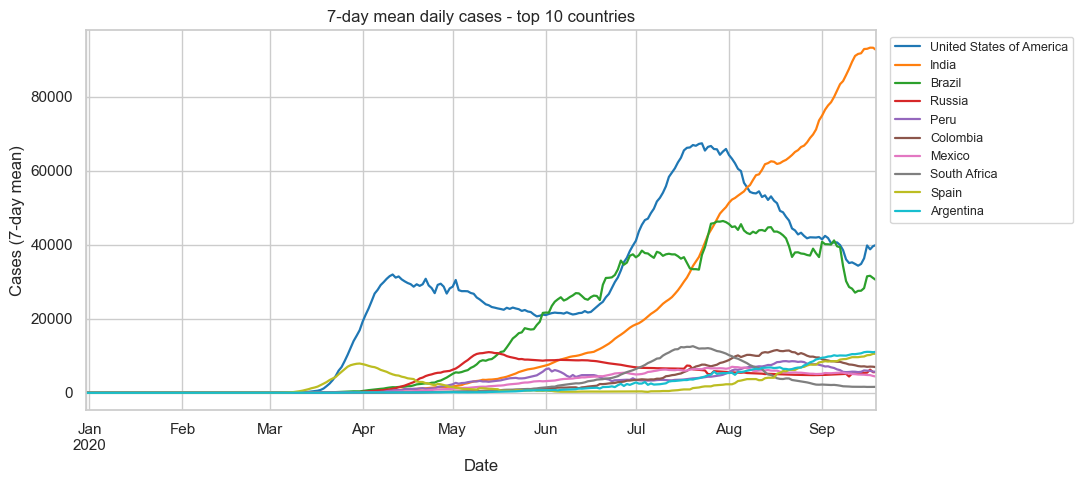

In [19]:
ax = w10.rolling(7, min_periods=1).mean().plot(
        lw=1.6, title='7-day mean daily cases - top 10 countries')
ax.set_xlabel('Date')
ax.set_ylabel('Cases (7-day mean)')
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

Long format would need a plotting grammar to map a column to colour - seaborn's `hue='country'`. Wide format needs nothing at all, because "one line per column" is already the layout.

Neither is better. It is the same chart, reached through different structure.

## 3.2 Column-aligned arithmetic: per-capita rates

Raw counts mostly measure population size. To compare countries fairly we need cases per 100,000 people - which means dividing each column by a *different* number.

In wide format this is one `div()` call. Build a population Series indexed by country, and pandas **aligns it to the column labels automatically**:

In [20]:
pop = df.groupby('country')['popData2019'].first()
pop[top10_names].round(0)

country
United States of America    3.290649e+08
India                       1.366418e+09
Brazil                      2.110495e+08
Russia                      1.458723e+08
Peru                        3.251046e+07
Colombia                    5.033944e+07
Mexico                      1.275755e+08
South Africa                5.855827e+07
Spain                       4.693706e+07
Argentina                   4.478068e+07
Name: popData2019, dtype: float64

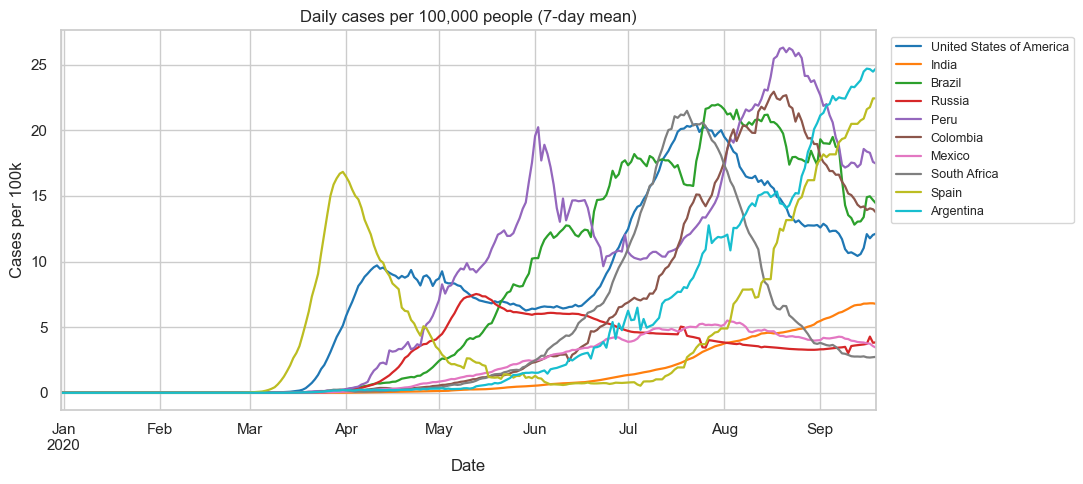

In [21]:
# div(axis=1) matches the Series index against the DataFrame columns.
per100k = w10.div(pop[top10_names], axis=1) * 1e5

ax = per100k.rolling(7, min_periods=1).mean().plot(
        lw=1.6, title='Daily cases per 100,000 people (7-day mean)')
ax.set_xlabel('Date')
ax.set_ylabel('Cases per 100k')
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

The ranking rearranges completely. Ranked by cumulative cases per 100,000, the order becomes Peru, Brazil, the US, Colombia, Spain, Argentina, South Africa, Russia, Mexico, India - India drops from 2nd on raw counts to last. Same data, same shape, one division, a different conclusion.

The alignment is the point. We never told pandas which population goes with which column; it matched on labels. Get a label wrong and you get a silent `NaN` rather than a wrong number, which is the failure mode you want.

In [22]:
# The reordering, stated explicitly rather than eyeballed off the chart.
burden = pd.DataFrame({
    'total_cases': totals.loc[top10_names, 'cases'],
    'per_100k': (totals.loc[top10_names, 'cases'] / pop[top10_names] * 1e5).round(0),
})
burden['rank_raw'] = burden['total_cases'].rank(ascending=False).astype(int)
burden['rank_per_capita'] = burden['per_100k'].rank(ascending=False).astype(int)
burden.sort_values('rank_per_capita')

,total_cases,per_100k,rank_raw,rank_per_capita
country,,,,
Peru,756412,2327.0,5,1
Brazil,4495183,2130.0,3,2
United States of America,6724667,2044.0,1,3
Colombia,750471,1491.0,6,4
Spain,640040,1364.0,9,5
Argentina,601700,1344.0,10,6
South Africa,657627,1123.0,8,7
Russia,1091186,748.0,4,8
Mexico,688954,540.0,7,9


## 3.3 Cumulative totals

`cumsum()` runs down every column at once. In long format this needs a `groupby().cumsum()` to stop the running total leaking across country boundaries; in wide format the boundaries *are* the columns, so there is nothing to guard against.

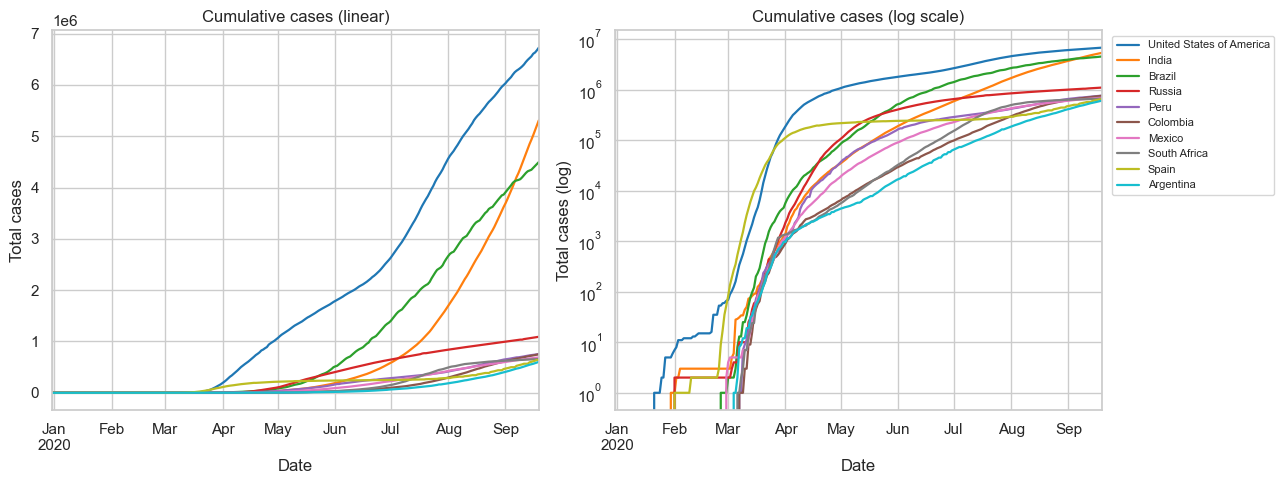

In [23]:
cum = w10.cumsum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cum.plot(ax=axes[0], lw=1.6, legend=False)
axes[0].set_title('Cumulative cases (linear)')
axes[0].set_ylabel('Total cases')
axes[0].set_xlabel('Date')

cum.plot(ax=axes[1], lw=1.6, logy=True)
axes[1].set_title('Cumulative cases (log scale)')
axes[1].set_ylabel('Total cases (log)')
axes[1].set_xlabel('Date')
axes[1].legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

On the log axis a straight line means constant exponential growth, and the *slope* is the growth rate. That comparison is only readable because the curves share an x-axis - which is what wide format guarantees.

## 3.4 Country-to-country correlation

Now something that is genuinely awkward in long format.

`.corr()` correlates **every column against every other column**, producing a 10 x 10 matrix. It works because the columns are already aligned on a shared date index - pandas can pair up observations without being told how.

To do this from long data you would first have to pivot. There is no way around it: correlation *needs* the matrix.

In [24]:
corr = w10.rolling(7, min_periods=1).mean().corr()
corr.round(2)

country,United States of America,India,Brazil,Russia,Peru,Colombia,Mexico,South Africa,Spain,Argentina
country,,,,,,,,,,
United States of America,1.00,0.68,0.87,0.60,0.75,0.79,0.89,0.84,0.37,0.66
India,0.68,1.00,0.79,0.30,0.81,0.93,0.77,0.46,0.69,1.00
Brazil,0.87,0.79,1.00,0.62,0.89,0.88,0.99,0.80,0.30,0.77
Russia,0.60,0.30,0.62,1.00,0.69,0.34,0.66,0.43,-0.01,0.29
Peru,0.75,0.81,0.89,0.69,1.00,0.86,0.87,0.51,0.43,0.79
Colombia,0.79,0.93,0.88,0.34,0.86,1.00,0.86,0.64,0.53,0.90
Mexico,0.89,0.77,0.99,0.66,0.87,0.86,1.00,0.83,0.28,0.75
South Africa,0.84,0.46,0.80,0.43,0.51,0.64,0.83,1.00,-0.02,0.44
Spain,0.37,0.69,0.30,-0.01,0.43,0.53,0.28,-0.02,1.00,0.71


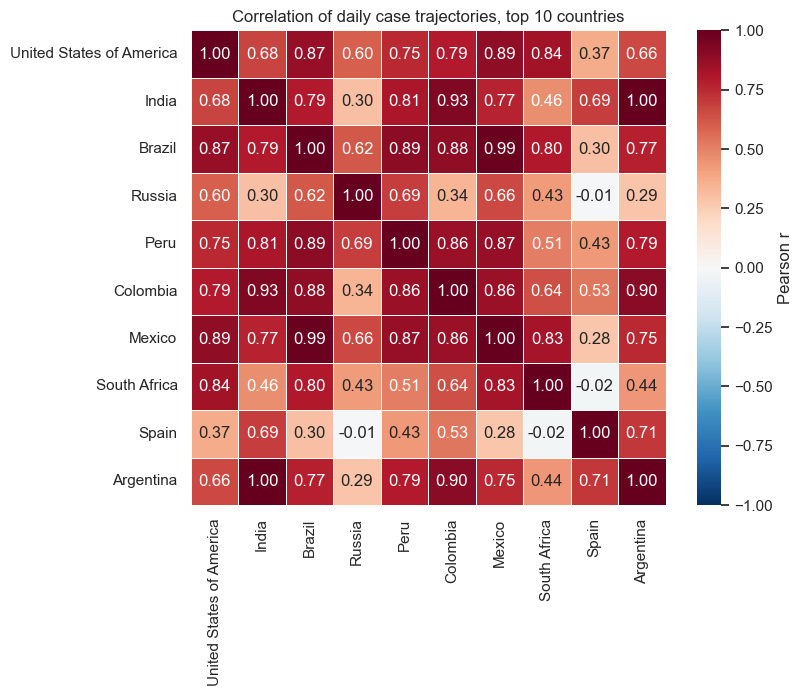

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=.5,
            cbar_kws={'label': 'Pearson r'}, ax=ax)
ax.set_title('Correlation of daily case trajectories, top 10 countries')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Read this as *shape similarity over time*, not as any causal link. Countries whose epidemics rose and fell on the same schedule score high. Spain correlates negatively with several South American countries simply because its spring wave had subsided by the time theirs peaked.

A caution worth stating plainly: both series here trend over time, and correlating two trending series inflates `r` regardless of any real relationship. Treat this as descriptive.

## 3.5 Aligning curves: days since the 100th case

Comparing epidemics by calendar date is misleading, because outbreaks started months apart. The standard fix is to re-zero each country's clock at a common milestone - here, its 100th cumulative case.

This means **each column gets a different time origin**. In wide format that is an `apply` over columns: drop the leading values below the threshold and reset each column to a 0-based counter.

In [26]:
cum_all = wide.cumsum()

aligned = cum_all.apply(lambda s: pd.Series(s[s >= 100].to_numpy()))
aligned.index.name = 'days_since_100th_case'

aligned10 = aligned[top10_names]
print(aligned10.shape)
aligned10.iloc[:5, :5]

(245, 10)


country,United States of America,India,Brazil,Russia,Peru
days_since_100th_case,,,,,
0,103.0,125.0,121.0,114.0,117.0
1,125.0,137.0,200.0,147.0,145.0
2,159.0,165.0,234.0,199.0,234.0
3,233.0,191.0,291.0,253.0,263.0
4,338.0,231.0,428.0,306.0,318.0


Each column now starts on *its own* day 0. Columns have different lengths, so pandas pads the short ones with `NaN` - which is exactly right, and plots as a line that simply stops.

This is the operation that most clearly favours wide format. In long format you would need a `groupby`, a per-group cumulative sum, a per-group filter for the threshold date, a `cumcount` to build the new counter, and a merge to reassemble - roughly six steps to express one idea.

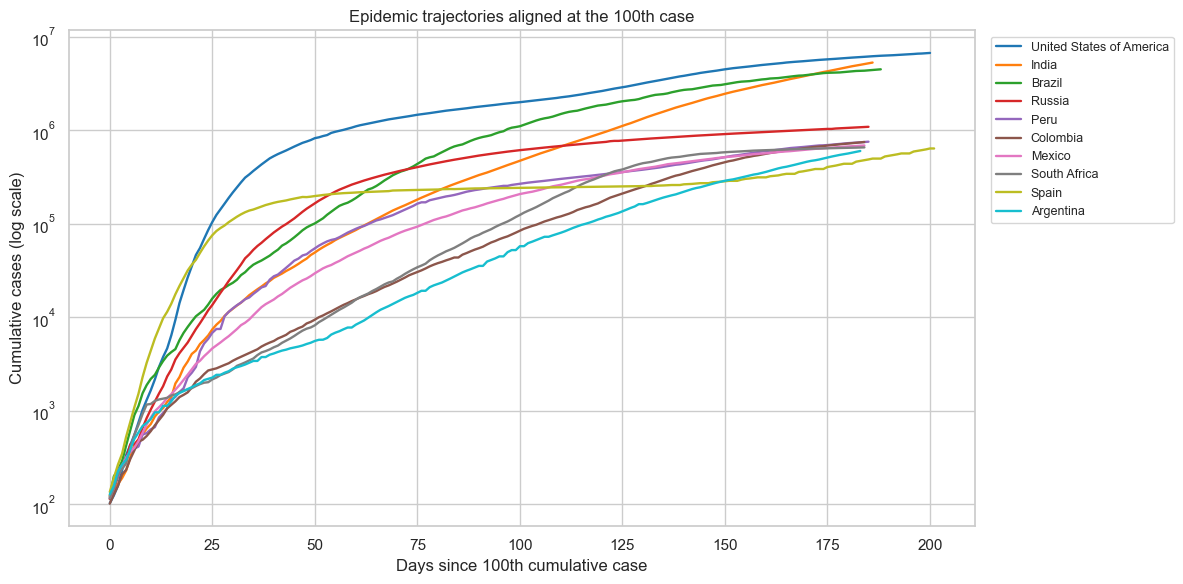

In [27]:
fig, ax = plt.subplots(figsize=(12, 6))
for c in top10_names:
    ax.plot(aligned10.index, aligned10[c], lw=1.7, label=c)
ax.set_yscale('log')
ax.set_title('Epidemic trajectories aligned at the 100th case')
ax.set_xlabel('Days since 100th cumulative case')
ax.set_ylabel('Cumulative cases (log scale)')
ax.legend(title='', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

With the calendar removed, the curves become directly comparable: the steeper the line, the faster that country's outbreak grew from the same starting point.

## 3.6 Ranking over time

One more matrix operation. `rank(axis=1)` ranks **across columns within each row** - who was worst on each individual day. The `axis=1` direction only means something because columns are comparable entities, which is the defining property of wide format.

In [28]:
monthly_cases = (df.pivot_table(index=df['dateRep'].dt.to_period('M'),
                                columns='country', values='cases', aggfunc='sum')
                   .fillna(0))

ranks = monthly_cases.rank(axis=1, ascending=False)[top10_names].astype(int)
ranks.T

dateRep,2019-12,2020-01,2020-02,2020-03,2020-04,2020-05,2020-06,2020-07,2020-08,2020-09
country,,,,,,,,,,
United States of America,106,9,8,1,1,1,2,1,2,2
India,106,18,37,40,14,4,3,3,1,1
Brazil,106,116,49,16,9,2,1,2,3,3
Russia,106,116,37,32,6,3,4,6,9,9
Peru,106,116,133,46,13,5,8,8,5,8
Colombia,106,116,133,48,41,23,13,7,4,7
Mexico,106,116,37,42,20,8,7,5,7,10
South Africa,106,116,133,38,45,18,9,4,10,21
Spain,106,116,9,2,3,19,45,22,8,5


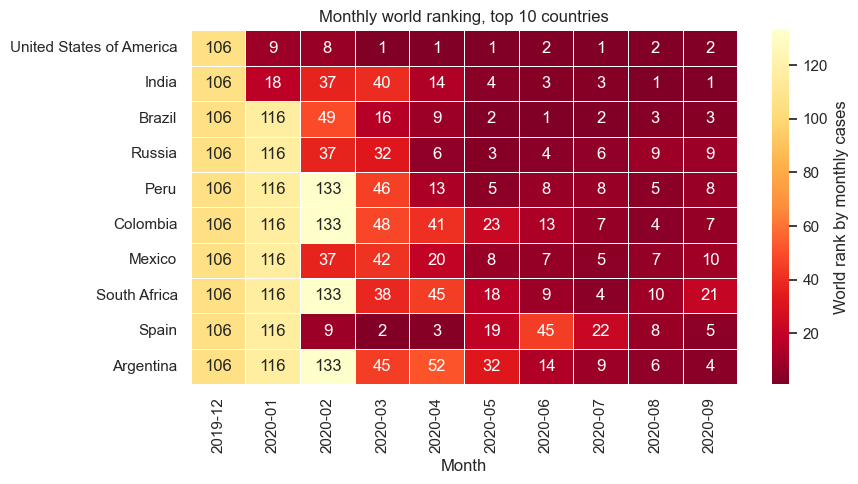

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(ranks.T, annot=True, fmt='d', cmap='YlOrRd_r',
            linewidths=.5, cbar_kws={'label': 'World rank by monthly cases'}, ax=ax)
ax.set_title('Monthly world ranking, top 10 countries')
ax.set_xlabel('Month')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

Read the ranks carefully: they are **world ranks across all 210 columns**, and we are only *displaying* ten of them. That is why our countries sit at 106 and 116 in December and January - the global leader in those months was China, which never enters the top 10 by cumulative total and so never appears in this subset.

From there the migration is readable: the US takes rank 1 in March and holds it through May, Spain spikes to rank 2 in March before falling away, Brazil takes over in June, and India climbs from rank 40 in March to rank 1 by August.

Computing a statistic over the full matrix and then slicing the result is a common and useful pattern - but you have to keep straight which of the two you are reading.

In [30]:
# Confirming the point: who actually led the world each month?
monthly_cases.idxmax(axis=1)

dateRep
2019-12                       China
2020-01                       China
2020-02                       China
2020-03    United States of America
2020-04    United States of America
2020-05    United States of America
2020-06                      Brazil
2020-07    United States of America
2020-08                       India
2020-09                       India
Freq: M, dtype: object

---

# Summary

| | long format | wide format |
|---|---|---|
| **one row is** | one observation | one time point |
| **entity identity lives in** | a column, as data | the column labels, as schema |
| **growing the data** | adds rows | adds columns |
| **filtering a subset** | boolean row mask | column selection |
| **aggregating by group** | `groupby()` - natural | needs transposing or `axis=1` |
| **per-group calculations** | `groupby().transform()` | column-wise by default |
| **plotting many series** | `hue=` / faceting | one line per column, free |
| **entity-to-entity comparison** | awkward - requires pivot | native (`.corr()`, arithmetic) |
| **per-entity scaling** | merge, then divide | `.div()` with label alignment |
| **missing coverage** | invisible - just fewer rows | explicit `NaN` cells |
| **best for** | storage, aggregation, grammar-of-graphics plotting | matrices, correlation, cross-entity math |

**The takeaway.** Long format keeps entity identity *in the data*, which is what makes `groupby` and `hue=` work. Wide format moves it *into the schema*, which is what makes matrix arithmetic and cross-entity comparison work.

Real analysis moves between the two constantly. Store long, reshape wide for the question at hand, reshape back. Fluency with `pivot` / `pivot_table` / `unstack` is what makes that movement cheap - and once it is cheap, you stop fighting your data's shape and start choosing it.